<h1 align="center">Generalized Linear Model</h1> 
<h3 align="center">BSAI course, Autumn, 2025</h3> 

In this tutorial we will go over some basic concepts and implementations of the Generalized Linear Models (GLMs). 

Reference:

- [Neuromatch GLM tutorial](https://compneuro.neuromatch.io/tutorials/W1D3_GeneralizedLinearModels/student/W1D3_Intro.html) The first three section of this tutorial mainly adapted from the GLM tutorial provided by Neuromatch Academy.

- [Cosyne 2018 GLM tutorial](https://www.youtube.com/watch?v=NFeGW5ljUoI) Section 4 of this tutorial is mainly inspired by the GLM tutorial of Jonathan Pillow in Cosyne 2018.

### Setup

First we import some packages and setup some plotting functions.

In [1]:
# Imports

import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from scipy.optimize import minimize
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# Plotting Functions

# Section 1, Section 2
def plot_spikes_with_prediction(spikes, predicted_spikes, dt=None, nt=50, t0=120, show=True, **kws):
  t = np.arange(t0, t0 + nt)
  if dt is not None: t = t * dt
  f, ax = plt.subplots()
  lines = ax.stem(t, spikes[t0:t0 + nt])
  plt.setp(lines, color=".5")
  lines[-1].set_zorder(1)
  kws.setdefault("linewidth", 3)
  yhat, = ax.plot(t, predicted_spikes[t0:t0 + nt], **kws)

  ax.set(
      xlabel="Image index" if dt is None else "Time (s)",
      ylabel="Spikes",
  )
  ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax.legend([lines[0], yhat], ["Spikes", "Predicted"])
  if show:
    plt.show()

# Section 2
def plot_spikes_with_multiple_predictions(spikes, predicted_list, dt=None,
                                          nt=50, t0=120, show=True, labels=None, colors=None, **kws):
    t = np.arange(t0, t0 + nt)
    if dt is not None: t = t * dt
    f, ax = plt.subplots()
    lines = ax.stem(t, spikes[t0:t0 + nt])
    plt.setp(lines, color=".5")
    lines[-1].set_zorder(1)
    if labels is None:
        labels = [f"Predicted {i+1}" for i in range(len(predicted_list))]
    if colors is None:
        colors = [None] * len(predicted_list)
    kws.setdefault("linewidth", 3)
    plot_handles = [lines[0]]
    legend_labels = ["Spikes"]
    for yhat, label, color in zip(predicted_list, labels, colors):
        handle, = ax.plot(t, yhat[t0:t0 + nt], label=label, color=color, **kws)
        plot_handles.append(handle)
        legend_labels.append(label)
    ax.set(
        xlabel="Image index" if dt is None else "Time (s)",
        ylabel="Spikes",
    )
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(plot_handles, legend_labels)
    if show:
        plt.show()

# Exercise 3.1
def plot_function(f, name, var, points=(-10, 10)):
    """Evaluate f() on linear space between points and plot.

    Args:
      f (callable): function that maps scalar -> scalar
      name (string): Function name for axis labels
      var (string): Variable name for axis labels.
      points (tuple): Args for np.linspace to create eval grid.
    """
    x = np.linspace(*points)
    ax = plt.figure().subplots()
    ax.plot(x, f(x))
    ax.set(
      xlabel=f'${var}$',
      ylabel=f'${name}({var})$'
    )
    plt.show()

# Bonus 3.2
def plot_model_selection(C_values, accuracies):
  """Plot the accuracy curve over log-spaced C values."""
  ax = plt.figure().subplots()
  ax.set_xscale("log")
  ax.plot(C_values, accuracies, marker="o")
  best_C = C_values[np.argmax(accuracies)]
  ax.set(
      xticks=C_values,
      xlabel="C",
      ylabel="Cross-validated accuracy",
      title=f"Best C: {best_C:1g} ({np.max(accuracies):.2%})",
  )
  plt.show()

# Bonus 3.3
def plot_non_zero_coefs(C_values, non_zero_l1, n_voxels):
  """Plot the accuracy curve over log-spaced C values."""
  ax = plt.figure().subplots()
  ax.set_xscale("log")
  ax.plot(C_values, non_zero_l1, marker="o")
  ax.set(
    xticks=C_values,
    xlabel="C",
    ylabel="Number of non-zero coefficients",
  )
  ax.axhline(n_voxels, color=".1", linestyle=":")
  ax.annotate("Total\n# Neurons", (C_values[0], n_voxels * .98), va="top")
  plt.show()

# Exercise 4.1
def plot_history_matrices(H, spikes, nt=50, t0=100):
  """
    Show H (history matrix) and spikes as heatmaps.

    Args:
    H (2D array): History matrix with values between 0 and 1, from make_post_spike_matrix.
    spikes (1D array): Spike vector (floating point values).
    nt (int): Number of time points to display.
    t0 (int): Starting time point for display.
  """
  # Ensure spikes is 2D and skinny
  spikes_2d = np.c_[spikes]  
  
  f, (ax_h, ax_spikes) = plt.subplots(
    ncols=2,
    figsize=(8, 8),
    sharey=True,
    gridspec_kw=dict(width_ratios=(4, 1)),
  )

  value_min = min(H[t0:t0+nt].min(), spikes[t0:t0+nt].min())
  value_max = max(H[t0:t0+nt].max(), spikes[t0:t0+nt].max())

  # Plot H matrix (spike history)
  # Use continuous colorbar for H values (0 to 1)
  imh = ax_h.pcolormesh(H[t0:t0+nt], cmap="viridis", vmin=value_min, vmax=value_max)

  # Set basic labels and title
  ax_h.set(
    title="H\n(spike history)",
    xlabel="History lag (time bins)",
    ylabel="Time point (time bins)",
  )
  
  # Set ticks and tick labels separately to avoid warnings
  x_tick_positions = np.arange(0, H.shape[1], max(1, H.shape[1]//5))
  x_tick_labels = np.arange(1, H.shape[1]+1, max(1, H.shape[1]//5))
  ax_h.set_xticks(x_tick_positions)
  ax_h.set_xticklabels(x_tick_labels[:len(x_tick_positions)])  # Ensure same length
  
  plt.setp(ax_h.spines.values(), visible=True)

  divh = make_axes_locatable(ax_h)
  caxh = divh.append_axes("right", size="5%", pad=0.1)
  cbarh = f.colorbar(imh, cax=caxh)
  # Set continuous ticks for H colorbar
  tick_values = np.linspace(value_min, value_max, 5)
  cbarh.set_ticks(tick_values)
  cbarh.set_ticklabels([f'{val:.2f}' for val in tick_values])

  # Plot spikes vector
  # Use continuous colormap for spikes (same as H matrix for consistency)
  im_spikes = ax_spikes.pcolormesh(spikes_2d[t0:t0+nt], cmap="viridis", vmin=value_min, vmax=value_max)
  ax_spikes.set(
    title="Spikes",
    xticks=[]
  )
  ax_spikes.invert_yaxis()
  plt.setp(ax_spikes.spines.values(), visible=True)

  div_spikes = make_axes_locatable(ax_spikes)
  cax_spikes = div_spikes.append_axes("right", size="30%", pad=0.1)
  cbar_spikes = f.colorbar(im_spikes, cax=cax_spikes)
  cbar_spikes.set_label('Spike value')
  # Set continuous ticks for spikes colorbar
  tick_values = np.linspace(value_min, value_max, 5)
  cbar_spikes.set_ticks(tick_values)
  cbar_spikes.set_ticklabels([f'{val:.2f}' for val in tick_values])
  
  plt.tight_layout()
  plt.show()

# Exercise 4.2
def plot_spike_filter(theta, dt, show=True, **kws):
  d = len(theta)
  t = np.arange(-d + 1, 1) * dt

  ax = plt.gca()
  ax.plot(t, theta, marker="o", **kws)
  ax.axhline(0, color=".2", linestyle="--", zorder=1)
  ax.set(
    xlabel="Time before spike (s)",
    ylabel="Filter weight",
  )
  if show:
    plt.show()

## 1. Linear Gaussian Model</h2>

In linear model, we find a parameter $\bm{\theta}$ (vector) to map input $\bm{x_i}$ (vector) to ouptut $\hat{y_i}$ (scalar) for each sample $i$, which can be formatted as

$$\hat{y_i} = \bm{\theta}^T\bm{x_i}$$

Linear Gaussian model adds Gaussian noise in this progress to better depict the randomness of $\hat{y_i}$:

$$\hat{y_i} = \bm{\theta}^T\bm{x_i} + \eta_i, \quad \eta_i \sim \mathcal{N}(0, \sigma^2), \forall i$$

Note that here we take $\sigma$ as a hyperparameter, which is determined in advance and we do not search it for best predicting performance.

Given $n$ samples, we collate the data as a vectorized version. We define $\bm{X}$ which takes $\bm{x_i}$ as rows, and define $\bm{\hat{y}}=\begin{pmatrix}\hat{y_1}\\ \vdots \\ \hat{y_n}\end{pmatrix}$, $\bm{\theta}=\begin{pmatrix}\theta_1\\ \vdots \\ \theta_n\end{pmatrix}$, $\bm{\bm{\eta}}=\begin{pmatrix}\eta_1\\ \vdots \\ \eta_n\end{pmatrix}$, and $\bm{\Sigma}=\sigma\bm{I}$. Then the linear Gaussian model can be formatted as:

$$\hat{\bm{y}} = \bm{X\theta} + \bm{\eta}, \quad {\eta} \sim \mathcal{N}(\bm{0}, \bm{\Sigma}^2)$$

### (1) Retinal ganglion cell (RGC) dataset
In this section we use the public dataset from the Gollisch lab. It contains spike trains from 156 retinal ganglion cells of isolated salamander retina recorded while presenting 303 natural images. We will use these data to build simple encoding/decoding GLM models.

- Source [GIN/G-Node](https://gin.g-node.org/gollischlab/Liu_Gollisch_2021_RGC_spiketrains_spatial_contrast_model) (you can see details of this dataset here)
- File used here: `rgc_data.h5` (corresponds to `response2naturalimages.h5` in the GIN/G-Node repository)
- Variables:
  - `spikes`: (156, 303, 13, 300)
    - 156 neurons × 303 images × 13 repeated trials × 300 time bins
    - The value is binary (0 or 1), indicating whether there is a spike
  - `images`: (303, 256, 256)
    - 303 grayscale images of size 256×256
  - `resolution`: we set resolution = 0.001 seconds/bin (1 ms)

This dataset is already uploaded to the cloud of this course. If you want to manually download it from the [GIN/G-Node](https://gin.g-node.org/gollischlab/Liu_Gollisch_2021_RGC_spiketrains_spatial_contrast_model) website, please download the `response2naturalimages.h5` to current directory and rename it to `rgc_data.h5`.

In [3]:
def load_rgc_data():
  """
  data:
    - spikes: (156, 303, 13, 300)
    - images: (303, 256, 256)
    - mu: (156, 2)
    - sigma: (156, 2, 2)
    - resolution: 0.001
  """
  f = h5py.File(f'rgc_data.h5', 'r')
  data = {}
  for key in f.keys():
     data[key] = np.array(f[key])
  f.close()
  data['resolution'] = 0.001
  del data['mu']
  del data['sigma']
  return data

rgc_data = load_rgc_data()
print("Data keys:", list(rgc_data.keys()))
for key, item in rgc_data.items():
    print(f"  {key}: {item.shape if isinstance(item, np.ndarray) else item}")

Data keys: ['images', 'spikes', 'resolution']
  images: (303, 256, 256)
  spikes: (156, 303, 13, 300)
  resolution: 0.001


We check some images.

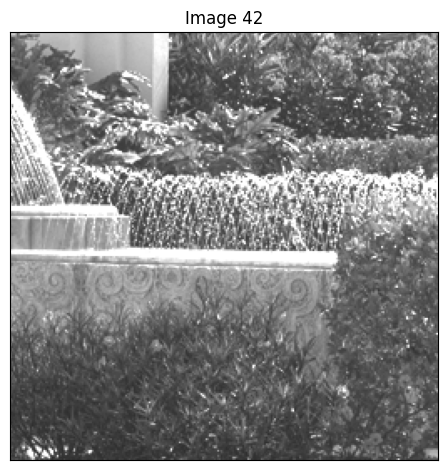

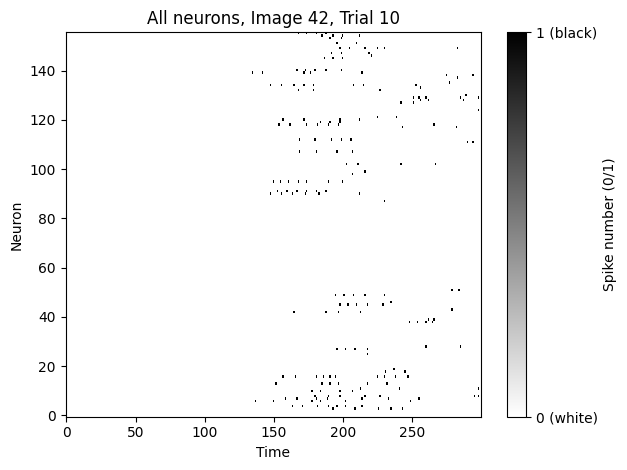

In [4]:
# you can change these values to view different images and trials
image_id = 42 # 0 ~ 302
trial_id = 10 # 0 ~ 12

plt.figure()
plt.imshow(np.transpose(rgc_data['images'][image_id, :, :]), cmap='gray', vmin=-1, vmax=1, origin='lower')
plt.title(f"Image {image_id}")
plt.xticks([])
plt.yticks([])
plt.tight_layout()

fig, ax = plt.subplots()
spike_mat_raw = rgc_data['spikes'][:, image_id, trial_id, :]  # shape: (n_neurons, n_timebins)
spike_mat = (spike_mat_raw > 0).astype(float)
im = ax.imshow(spike_mat, aspect='auto', origin='lower', interpolation='nearest', cmap='gray_r', vmin=0, vmax=1)
ax.set_xlabel('Time')
ax.set_ylabel('Neuron')
ax.set_title(f"All neurons, Image {image_id}, Trial {trial_id}")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Spike number (0/1)')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0 (white)', '1 (black)'])
plt.tight_layout()

For simplicity, we downsample the image from 256\*256 to 16\*16 as `stim_data`, and take the sum of spikes across the trial to each image as `spike_data`, mean over trials.

In [5]:
def collate_rgc_data_1(imagedata, spikedata):
    """
    Downsample the image from 256*256 to 16*16.
    Mean spikes over trials, then sum over time bins.
    Args:
      imagedata: (303, 256, 256)
      spikedata: (156, 303, 13, 300)
    Return:
      stim_data: (303, 16*16)
      spike_data: (303, 156)
    """
    stim_data = imagedata.reshape(303, 16, int(256/16), 16, int(256/16)).mean(axis=3).mean(axis=1) # (303, 16, 16)
    spike_data = spikedata.mean(axis=2).sum(axis=2).transpose(1,0) # (303, 156)
    return stim_data, spike_data

# collate rgc data
stim_data, spike_data = collate_rgc_data_1(rgc_data['images'], rgc_data['spikes'])
print(f"stim_data shape: {stim_data.shape}, spike_data.shape: {spike_data.shape}")

stim_data shape: (303, 16, 16), spike_data.shape: (303, 156)


### (2) Create design matrix

We use Linear Gaussian model as an `encoding model`, which means the model maps the stimulus to the corresponding neural activities. For the rgc dataset, the images are the input samples $\bm{x_i}$, and averaged total spike counts of a neuron during a trial of an image are the output samples $\bm{y_i}$.

Recall $\hat{\bm{y}} = \bm{X\theta} + \bm{\eta}, \quad {\eta} \sim \mathcal{N}(\bm{0}, \bm{\Sigma}^2)$, where $\bm{X}$ takes input samples $\bm{x_i}$ as rows. Here we call $\bm{X}$ the `design matrix`.

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 1.1:</b>

Try building the `design matrix` $\bm{X}$.
</div>

In [6]:
def make_design_matrix(stim):
    """
    Args:
      stim: (303, 16, 16)
    Return:
      X: the design matrix, take each row as a sample
    """
    X = stim.reshape(stim.shape[0], -1)  
    return X

design_matrix = make_design_matrix(stim_data)
print(design_matrix.shape)

(303, 256)


### (3) Solve linear Gaussian model

To accuratly predict spike counts from the stimulus images, we need to adjust the parameter $\bm{\theta}$ to minimize the discripency between the predicted spike counts $\hat{\bm{y}}$ and the true spike counts $\bm{y}$.

---

On the one hand, we could minimize the square error between the expected prediction ($\bm{X\theta}$) and the truth ($\bm{y}$). We call this method **Least Squares Estimation (LSE)**.

$$\bm{\theta^*} = \argmin\limits_{\theta}\parallel\bm{X\theta-y}\parallel_2^2 = \argmin\limits_{\theta}\sum\limits_{t=1}^{T}(y_t-\bm{\theta^Tx_t})^2$$

By setting the differential of $\bm{\theta}$ to zero, we could find local minima of the function.

$$
\begin{align*}
\frac{\partial\|X\boldsymbol{\theta}-\boldsymbol{y}\|_2^2}{\partial\boldsymbol{\theta}}&=2X^\top(X\boldsymbol{\theta}-\boldsymbol{y})=0\\
\Rightarrow\qquad\qquad\boldsymbol{\theta}_{\mathrm{LSE}}&=(X^\top X)^{-1}X^\top\boldsymbol{y}
\end{align*}
$$

*(Derivation hint:)*
$$
\begin{align*}
\|X\boldsymbol{\theta}-\boldsymbol{y}\|_2^2&=(X\boldsymbol{\theta}-\boldsymbol{y})^T(X\boldsymbol{\theta}-\boldsymbol{y})\\
&=\boldsymbol{\theta}^TX^TX\boldsymbol{\theta}-2\boldsymbol{y}^TX\boldsymbol{\theta}+\boldsymbol{y}^T\boldsymbol{y}
\end{align*}
$$
$$
\frac{\partial(\boldsymbol{\theta}^TA\boldsymbol{\theta})}{\partial\boldsymbol{\theta}}=2A\boldsymbol{\theta},\quad {\rm if\ }A{\rm\ is\ symmetric}\\
\frac{\partial(\boldsymbol{a}^T\boldsymbol{\theta})}{\partial\boldsymbol{\theta}}=\boldsymbol{a}
$$

---

On the other hand, we could get $\bm{\theta}$ by maximizing the log likelihood of $\bm{\theta}$ given data pair $(\bm{X}, \bm{y})$. We call this method **Maximize Likelihood Estimation (MLE)**.

Recall that the Gaussian probability function is:

$${\rm P_{Gaussian}}(\bm{x}|\bm{\mu},\bm{\Sigma})=\frac{1}{\sqrt{(2\pi)^k|\bm{\Sigma}|}}\exp{(-\frac{1}{2}(\bm{x-\mu})\bm{\Sigma}^{-1}(\bm{x-\mu}))}$$

The likelihood $L(\bm{\theta}|\bm{X,y}) = {\rm P_{Gaussaion}(\bm{y|X,\theta})}$, then we have:

$$
\begin{align*}
\bm{\theta^*} &= \argmax\limits_{\theta}\log L(\bm{\theta|X,y})\\
&= \argmax\limits_{\theta}[-\frac{N}{2}\log 2\pi\sigma^2 - \frac{1}{2\sigma^2}(\bm{y-X\theta})^T(\bm{y-X\theta})]
\end{align*}
$$
where $N$ is the dimensionality of $\bm{y}$ (the number of images).

$$
\begin{align*}
\frac{\partial\log L(\bm{\theta|X,y})}{\partial\boldsymbol{\theta}}&=-\frac{1}{\sigma^2}\bm{X^T}(\bm{X\theta-y})=0\\
\Rightarrow\qquad\qquad\boldsymbol{\theta}_{\mathrm{MLE}}&=(X^\top X)^{-1}X^\top\boldsymbol{y}
\end{align*}
$$

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 1.2:</b>

Try implementing the linear Gaussian model.
</div>

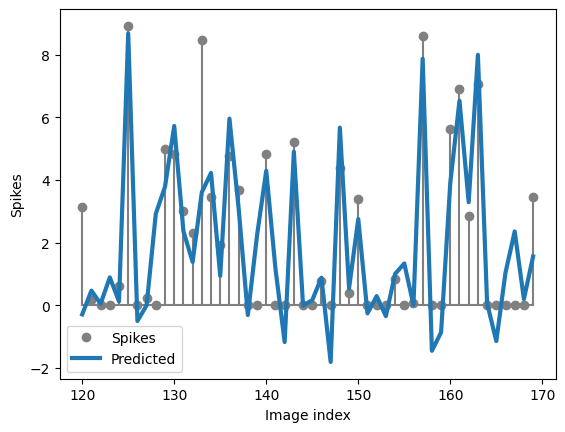

In [7]:
def predict_spike_counts_lg(stim, spikes):
  # Create the design matrix
  y = spikes
  X = make_design_matrix(stim)

  # Get the MLE weights for the LG model
  theta = np.linalg.pinv(X) @ y

  # Compute predicted spike counts
  yhat = X @ theta

  return yhat, theta

neuron_id = 5
# Predict spike counts
yhat_lg, theta_lg = predict_spike_counts_lg(stim_data, spike_data[:, neuron_id])
# Visualize
plot_spikes_with_prediction(
  spike_data[:, neuron_id], yhat_lg, nt=50, t0=120, color="C0")

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 1.3:</b>

We could add bias to the prediction to better predict spike counts.

To be specific, we change $\hat{\bm{y}} = \bm{X\theta} + \bm{\eta}$ to $\hat{\bm{y}} = \bm{X\theta} + \bm{b} + \bm{\eta}$.

Actually, for simplicity of implementation, we could change $\bm{x_i}$ to $\begin{pmatrix}1\\ x_{i,1}\\ \vdots \\ x_{i,d}\end{pmatrix}$ (where $d$ is the dimensionality of $\bm{x_i}$). The $\bm{\theta}$ will be correspondingly changed to $\begin{pmatrix}b\\ \theta_1\\ \vdots \\ \theta_d\end{pmatrix}$.

</div>

bias: 1.869


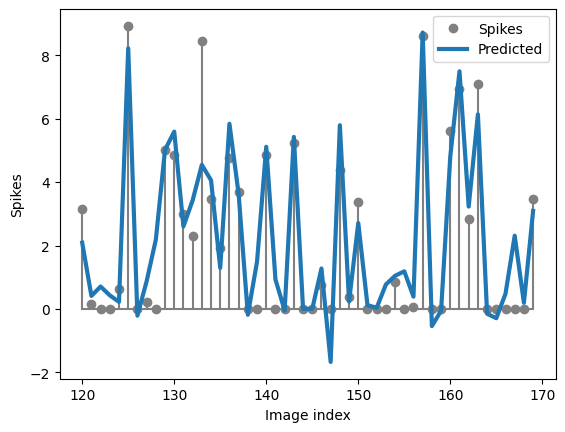

In [8]:
def predict_spike_counts_lg(stim, spikes):
  # Create the design matrix
  y = spikes
  constant = np.ones((len(y), 1))
  X = np.hstack((constant, make_design_matrix(stim)))

  # Get the MLE weights for the LG model
  theta_with_bias = np.linalg.pinv(X) @ y

  # Compute predicted spike counts
  yhat = X @ theta_with_bias

  bias = theta_with_bias[0]
  theta = theta_with_bias[1:]
  return yhat, theta, bias

neuron_id = 5
# Predict spike counts
yhat_lg_2, theta_lg_2, bias_lg_2 = predict_spike_counts_lg(stim_data, spike_data[:, neuron_id])
# Visualize
print(f"bias: {bias_lg_2:.3f}")
plot_spikes_with_prediction(
  spike_data[:, neuron_id], yhat_lg_2, nt=50, t0=120, color="C0")

## 2. Poisson GLM

The Poisson GLM is also called the **LNP (Linear–Nonlinear–Poisson)** model. We first apply a linear filter to the input (Linear), pass the result through a nonlinearity to obtain a nonnegative firing rate (Nonlinear), and then model spike counts with a Poisson distribution (Noise).

In general, a GLM is of such linear-nonlinear-noise structure, therefore GLM is also called **cascade model**. Here the nonlinear function is called **nonlinearity**, and its reverse is called **link function**.

Here we conduct MLE for Poisson GLM. Let the design matrix be $\mathbf{X} \in \mathbb{R}^{n\times d}$ and the parameters (filter weights) be $\theta \in \mathbb{R}^{d}$. For sample $i$, the linear term is $\mathbf{x}_i^{\top}\theta$, and the rate after the exponential nonlinearity is $\lambda_i = \exp(\mathbf{x}_i^{\top}\theta)$. We assume the observed spike count $y_i$ follows

$$y_i \sim \text{Poisson}(\lambda_i), \quad P(y_i\mid\mathbf{x}_i,\theta) = \dfrac{\lambda_i^{y_i} e^{-\lambda_i}}{y_i!}$$

The log-likelihood over all bins is

$$\log P(\mathbf{y}\mid\mathbf{X},\theta) = \sum_{i=1}^n \big[y_i\log\lambda_i - \lambda_i - \log(y_i!)\big], \quad \lambda_i = \exp(\mathbf{x}_i^{\top}\theta)$$

Since $\log(y_i!)$ does not depend on $\theta$, we can drop it for optimization. We denote log likelihood as $\ell$. In matrix form (with elementwise $\exp$ and $\log$) we have:

$$\ell(\theta) = \mathbf{y}^{\top}\log\boldsymbol{\lambda} - \mathbf{1}^{\top}\boldsymbol{\lambda}, \quad \boldsymbol{\lambda} = \exp(\mathbf{X}\theta)$$

We minimize the negative log-likelihood (NLL):

$$\mathcal{L}(\theta) = -\ell(\theta) = -\mathbf{y}^{\top}\log\boldsymbol{\lambda} + \mathbf{1}^{\top}\boldsymbol{\lambda}$$

### (1) Get negative log-likelihood

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 2.1:</b>

Try implementing the negative log likelihood used here ($\exp$ nonlinearity + Poisson noise).
</div>

In [9]:
def neg_log_lik_lnp(theta, X, y):
  # Compute the Poisson negative log likelihood
  rate = np.exp(X @ theta)
  log_lik = np.sum(y * np.log(rate) - rate)
  return -log_lik

example_X = np.array([[1, 0.5], [1, 1.0], [1, 1.5]])
example_y = np.array([0, 1, 2])
print(neg_log_lik_lnp(np.zeros(example_X.shape[1]), example_X, example_y))

3.0


Now we need to solve this optimization problem for the negative log-likelihood. Unlike the linear Gaussian Model, there is no closed-form solution here, so we need to use numerical optimization methods to solve the problem.

### (2) Optimization methods

`scipy.optimize.minimize` (we have imported it as `minimize` at the beginning of this tutorial) is a general-purpose optimizer for unconstrained and constrained optimization problems.

A basic signature for usage: minimize(func, x0, args)

 Conceptually, you provide:
- an objective function `func(theta, *args)` that returns a scalar (the value to minimize),
- an initial guess `x0`,
- the arguments `args` which corresponding to `func(theta, *args)`

---

When using numerical optimization methods, we need to be cautious that the solver may be caught in a **local minimum**.

A local minimum is a point where the objective is lower than all nearby points, but not necessarily the lowest value overall. In contrast, a global minimum is the lowest value over the entire domain. In non‑convex problems, the surface can have many local minima/saddles, and different starting points can end up in different solutions.

Below we check examples to better understand the concept of local minima.
- For a simple convex quadratic like $f(x)=x^2$, different starting points converge to the same optimum but may take different paths/iterations.
- For an oscillatory, non‑convex function like $g(x)=x/5+\cos x$, different starting points can land in different basins of attraction (different local minima).


Minimum value: 3.566e-16 at x = -1.88846e-08


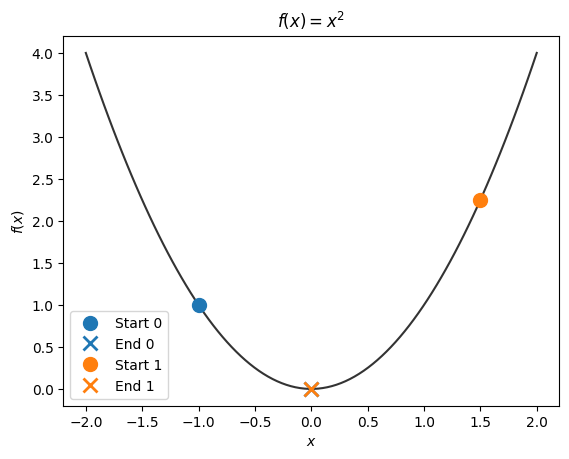

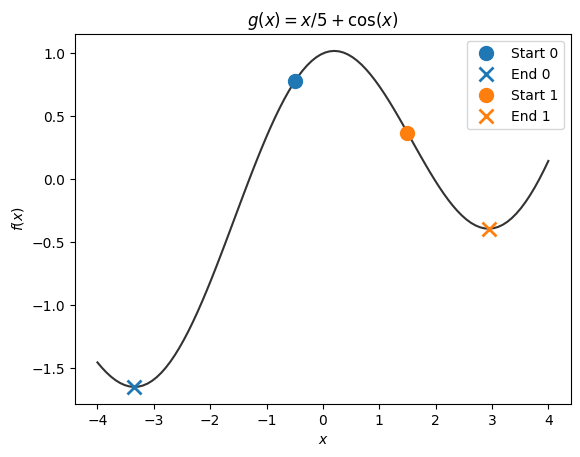

In [10]:
def plot_example_minimize_curve(xx, f, start_points, title=None):
  plt.plot(xx, f(xx), color=".2")
  plt.xlabel("$x$")
  plt.ylabel("$f(x)$")
  for i, x0 in enumerate(start_points):
    res = minimize(f, x0)
    plt.plot(x0, f(x0), "o", color=f"C{i}", ms=10, label=f"Start {i}")
    plt.plot(res["x"].item(), res["fun"], "x", color=f"C{i}",
             ms=10, mew=2, label=f"End {i}")
  if title is not None:
    plt.title(title)
  plt.legend()
  plt.show()

f = np.square
res = minimize(f, x0=2)
print(f"Minimum value: {res['fun']:.4g} at x = {res['x'].item():.5e}")

start_points = -1, 1.5
xx = np.linspace(-2, 2, 100)
plot_example_minimize_curve(xx, f, start_points, title="$f(x) = x^2$")

g = lambda x: x / 5 + np.cos(x)
start_points = -.5, 1.5
xx = np.linspace(-4, 4, 100)
plot_example_minimize_curve(xx, g, start_points, title="$g(x) = x/5 + \\cos(x)$")

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 2.2:</b>

Try implementing Poisson GLM. It might take some time to solve.

</div>

Hint:
- `fun`: returns the NLL given parameters `theta` and data `(X, y)` via `args`.
- `x0`: a vector of length `d` (number of parameters, including bias). Zeros or small Gaussian noise are common.
- `method`: quasi-Newton methods like `'BFGS'` or `'L-BFGS-B'` work well in practice; `'Newton-CG'` or `'trust-constr'` can benefit if you provide `jac`/`hess`.
- `jac`: if you supply the gradient, convergence is usually faster and more reliable. Otherwise SciPy will approximate it numerically.
- `options`: e.g., `{'maxiter': 1000, 'gtol': 1e-6}` to control iterations and tolerances.
- Return value: an `OptimizeResult` with fields like `.x` (parameters), `.fun` (objective), `.success`, `.nit` (iterations), `.message`.

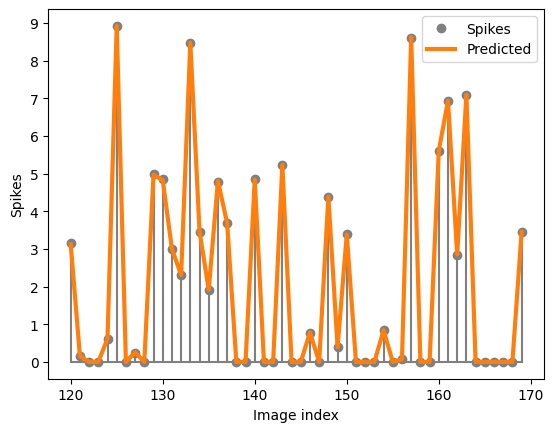

In [11]:
def predict_spike_counts_lnp(stim, spikes, theta=None):
  # Build the design matrix (with bias term)
  y = spikes
  X = np.hstack((np.ones((len(y), 1)), make_design_matrix(stim)))

  # Use a random vector of weights to start (mean 0, sd .2)
  np.random.seed(0)
  x0 = np.random.normal(0, .2, X.shape[1])
  
  # Find parameters that minimize the negative log likelihood function
  # Hint: use the minimize function as minimize(func, x0, args=(...))
  # Hint: 'args' is the parameters of your function starting from the second one
  #       i.e. your fucntion is defined as func(theta, *args)
  # Hint: add '.x' to get the weights (theta) from the result
  theta = minimize(neg_log_lik_lnp, x0, args=(X, y),
                   method='BFGS', options = {'maxiter': 10000, 'gtol': 1e-6}).x


  # Hint: yhat is the predicted lambda
  yhat = np.exp(X @ theta)
  return yhat, theta


# Predict spike counts
yhat_lnp, theta_lnp = predict_spike_counts_lnp(stim_data, spike_data[:, neuron_id])

# Visualize
plot_spikes_with_prediction(spike_data[:, neuron_id], yhat_lnp,
                            nt=50, t0=120, color="C1")

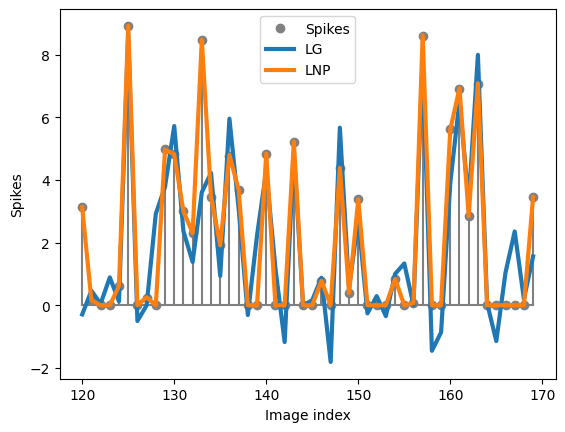

In [12]:
plot_spikes_with_multiple_predictions(
   spike_data[:, neuron_id], [yhat_lg, yhat_lnp],
   show=True, labels=["LG", "LNP"], colors=["C0", "C1"]
)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f6f8d9ff; ">

**Bonus 1. Linear nonlinear Gaussian model**

Try implementing linear nonlinear Gaussian model. Please set the `method` argument of `minimize` to `L-BFGS-B`.

**Bonus of bonus**: try provide the method for computing the gradient vector as argument `jac` in `minimize` to improve the performance.

**Hint**:
$$
\hat{y}=\exp(X\boldsymbol{\theta})\\
\log p(y|X,\boldsymbol{\theta})\propto -\frac{1}{2}\sum\limits_i(y_i-\hat{y}_i)^2\\
$$
$$
\begin{align*}
\nabla_\theta [\frac{1}{2}\sum\limits_i(y_i-\hat{y}_i)^2]
&= \sum\limits_i-(y_i-\hat{y}_i)\nabla_\theta\hat{y}_i\\
&= \sum\limits_i-(y_i-\hat{y}_i)\hat{y}_i X_i^T,\quad {\rm where\ }X_i{\rm\ is\ the\ ith\ row\ of\ }X\\
&= X^T[(\hat{y}-y)\odot\hat{y}]
\end{align*}
$$

</div>

In [13]:
def neg_log_lik_lng(theta, X, y):
    log_lik = ... # your code here
    return -log_lik

def predict_spike_counts_lng(stim, spikes, theta=None):
    y = spikes
    X = ... # your code here
    np.random.seed(0)
    x0 = np.random.normal(0, .2, X.shape[1])
    # Set 'method=L-BFGS-B' in minimize() if not use jac
    theta = ... # your code here
    yhat = np.exp(X @ theta)
    return yhat, theta

def grad_neg_log_lik_lng(theta, X, y):
    # Gradient of negative log likelihood w.r.t. θ
    grad = ... # your code here
    return grad

def predict_spike_counts_lng_jac(stim, spikes, theta=None):
    y = spikes
    X = ... # your code here
    x0 = np.random.normal(0, .2, X.shape[1])
    # Bonus of bonus: Implement 'grad_neg_log_lik_log' to use 'jac' in minimize().
    theta = ... # your code here
    yhat = np.exp(X @ theta)
    return yhat, theta


yhat_lng, theta_lng = predict_spike_counts_lng(stim_data, spike_data[:, neuron_id])
plot_spikes_with_prediction(spike_data[:, neuron_id], yhat_lng, nt=50, t0=120, color="C3")

# If you do not implemented 'grad_neg_log_lik_log', comment the two lines below
yhat_lng, theta_lng = predict_spike_counts_lng_jac(stim_data, spike_data[:, neuron_id])
plot_spikes_with_prediction(spike_data[:, neuron_id], yhat_lng, nt=50, t0=120, color="C4")

AttributeError: 'ellipsis' object has no attribute 'shape'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f6f8d9ff; ">

**Bonus 2. Thinking the selection of nonlinearity**

We use exponential nonlinearity in Poisson GLM. Can we use other nonlinearities, such as $\sin()$ as nonlinearity here? What if we use uniform distribution as nonlinearity?
</div>

# 3.Bernoulli GLM (Logistic Regression)

A Bernoulli Generalized Linear Model (GLM) is used for binary outcomes $y_i \in \{0,1\}$, e.g., spike/no-spike, success/failure, or yes/no decisions.

- **Linear predictor**: $\eta_i = \mathbf{x}_i^\top \boldsymbol{\theta} + b$ (features $\mathbf{x}_i$, weights $\boldsymbol{\theta}$, bias $b$)
- **Nonlinearity** (sigmoid, aka logistic): $\displaystyle p_i = \sigma(\eta_i) = \frac{1}{1 + e^{-\eta_i}}$ (This mapping guarantees $p_i \in (0,1)$ and yields a convex (well-behaved) optimization problem for maximum likelihood.)
- **Noise** (Bernoulli): $\Pr(y_i\mid p_i) = p_i^{y_i}(1-p_i)^{1-y_i}$

Negative log-likelihood (NLL), aka binary cross-entropy loss:  
$$\displaystyle \mathcal{L}_{\text{NLL}}(\boldsymbol{\theta}, b) = -\sum_{i} \Big[ y_i\,\log p_i + (1-y_i)\,\log(1-p_i) \Big]$$


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 3.1:</b>

Try implementing the logistic function, i.e. the sigmoid function.
</div>

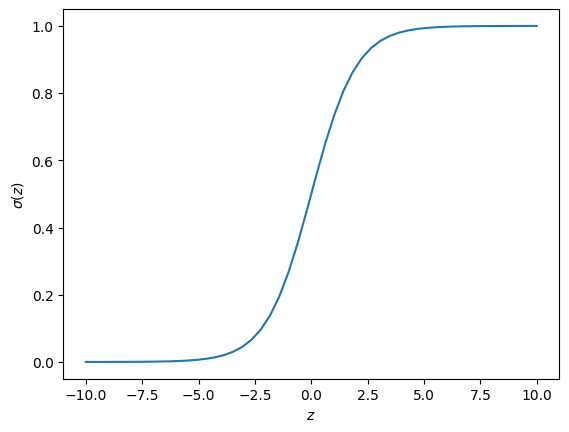

In [14]:
def sigmoid(z):
  sigmoid = 1 / (1 + np.exp(-z))
  return sigmoid

# Visualize
plot_function(sigmoid, "\\sigma", "z", (-10, 10))

### (1) Prepare data

We use Bernoulli GLM to predict binary choices. Here we define the choices to be 'whether the specific neuron ever fires during a trial to a specific image'. We first sum up the spike counts across the entire trial (300ms), then average over trials, and finally check if the averaged total spike counts is greater than 0.

In [15]:
def collate_rgc_data_2(imagedata, spikedata,
                       images_id=None, neuron_id=5):
    stim_data = imagedata.reshape(303, 16, int(256/16), 16, int(256/16)).mean(axis=3).mean(axis=1).reshape(303, -1) # (303, 16*16)
    spike_data = spikedata # (156, 303, 13, 300)
    if images_id is None: images_id = np.arange(100, 150)
    stim_data = stim_data[images_id, :]  # (50, 16*16) by default
    spike_data = spike_data[neuron_id, images_id, :, :].sum(-1).mean(-1) # (50,) by default
    return stim_data, spike_data

stim_data, spike_data = collate_rgc_data_2(rgc_data['images'], rgc_data['spikes'])

print(f"stim_data.shape: {stim_data.shape}\nspike_data.shape: {spike_data.shape}")
choices = spike_data > 0
print(f"choices: {choices}")

stim_data.shape: (50, 256)
spike_data.shape: (50,)
choices: [ True  True  True False  True  True False False  True  True  True False
  True  True  True  True  True  True  True  True  True  True False False
  True  True False  True False  True  True  True  True  True  True  True
  True  True False False  True False False  True False False  True False
  True  True]


### (2) Solve Bernoulli GLM

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 3.2:</b>

Try implementing the accuracy calculating. The accuracy is defined as the proportion of correct predictions.
</div>

In [16]:
def compute_accuracy(y, yhat):
  accuracy = np.mean(y == yhat)
  return accuracy

tmp_y = np.array([0, 1, 0, 1, 0, 1])
tmp_yhat = np.array([0, 0, 0, 1, 1, 1])
print(compute_accuracy(tmp_y, tmp_yhat))

0.6666666666666666


Here we directly use `sklearn.linear_model.LogisticRegression` (which is imported as `LogisticRegression` at the beginning of this tutorial) to perform logistic regression. Check its [document](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) for more details.

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 3.3:</b>

Try predicting the $\hat{y}$ using Bernoulli GLM i.e. LogisticRegression.
</div>

Accuracy on the training data: 100.00%


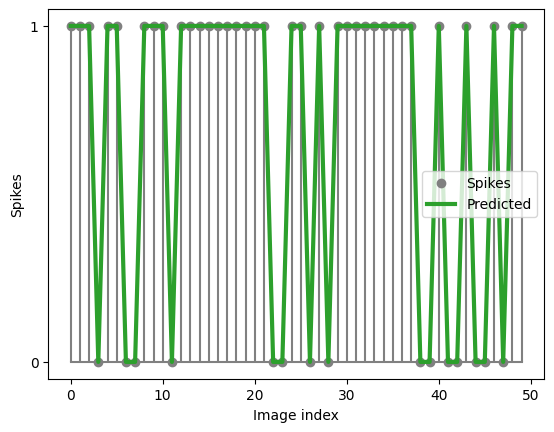

In [17]:
def predict_spike_counts_logistic(spikes, choices):
  # Build the design matrix (without bias term)
  X = spikes
  y = choices
  log_reg = LogisticRegression(penalty=None)
  log_reg.fit(X, y)

  # Compute predicted spike counts
  # Hint: use the .predict() method of the LogisticRegression class
  yhat = log_reg.predict(X)
  return yhat

yhat_logistic = predict_spike_counts_logistic(stim_data, choices)
# Compute train accuracy
train_accuracy = compute_accuracy(choices, yhat_logistic)
print(f"Accuracy on the training data: {train_accuracy:.2%}")
# Visualize
plot_spikes_with_prediction(choices, yhat_logistic, nt=50, t0=0, color="C2")

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f6f8d9ff; ">

**Bonus 3. Regularization**

##### (1) Cross validation

The accuracy in the above cell is 100%! It may seem impressive, but in practice it often indicates *overfitting*, where the model has memorized idiosyncrasies of the training data rather than learning the true underlying mapping from inputs to labels. As a result, its performance on unseen data is likely to degrade.

To assess generalization, we evaluate the model using cross-validated accuracy.  
`scikit-learn` provides the `cross_val_score` function for this purpose. It takes a model (e.g., `LogisticRegression`) and the data (`X`, `y`), then repeatedly splits the data into training and validation folds, trains the model on each training fold, and reports the accuracy on the corresponding validation fold. This yields a more reliable estimate of out-of-sample performance.

A picture from [Kording Lab](https://kordinglab.com/images/others/justCV-01.png) explains cross-validation well. The following code cell shows an example of corss-validation.

</div>

<div>
<img src="http://kordinglab.com/images/others/justCV-01.png", width="900"/>
</div>

In [ ]:
# cross-validation
accuracies = cross_val_score(LogisticRegression(penalty=None),
                             stim_data, choices, cv=8)  # k=8 cross validation

f, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(accuracies, vert=False, widths=.7)
ax.scatter(accuracies, np.ones(8))
ax.set(
  xlabel="Accuracy",
  yticks=[],
  title=f"Average test accuracy: {accuracies.mean():.2%}"
)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f6f8d9ff; ">

##### (2) $L_2$ regularization

**Regularization** is a technique used to mitigate overfitting by adding a penalty term to the model’s loss function, which discourages overly complex or extreme parameter values. A very common regularization uses an $L_2$ or "ridge" penalty. This changes the objective function to

$$
-\log\mathcal{L}'(\theta | X, y)= -\log\mathcal{L}(\theta | X, y) +\frac\beta2\sum_i\theta_i^2,
$$

where $\beta$ is a *hyperparameter* that sets the *strength* of the regularization.

You can use regularization in `scikit-learn` by changing the `penalty`, and you can set the strength of the regularization with the `C` hyperparameter ($C = \frac{1}{\beta}$, so this sets the *inverse* regularization).

</div>

In [ ]:
def model_selection(X, y, C_values):
  accuracies = []
  for C in C_values:
    model = LogisticRegression(..., max_iter=5000) # your code here
    accs = ... # your code here
    accuracies.append(...) # your code here
  return accuracies

# Use log-spaced values for C
C_values = np.logspace(-4, 4, 9)
# Compute accuracies
accuracies = model_selection(stim_data, choices, C_values)
# Visualize
plot_model_selection(C_values, accuracies)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f6f8d9ff; ">

##### (3) $L_1$ regularization

$L_2$ is not the only option for regularization. There is also the $L_1$, or "Lasso" penalty. This changes the objective function to

$$
-\log\mathcal{L}'(\theta | X, y) = -\log\mathcal{L}(\theta | X, y) +\frac\beta2\sum_i|\theta_i|
$$

In practice, using the summed absolute values of the weights causes *sparsity*: instead of just getting smaller, some of the weights will get forced to $0$:

</div>

In [ ]:
def count_non_zero_coefs(X, y, C_values):
  non_zero_coefs = []
  for C in C_values:
    model = LogisticRegression(..., solver="saga", max_iter=5000) # your code here
    ... # your code here
    # Get the coefs of the fit model (in sklearn, we can do this using model.coef_)
    coefs = ... # your code here
    # Count the number of non-zero elements in coefs
    non_zero = ... # your code here
    non_zero_coefs.append(non_zero)
  return non_zero_coefs

# Use log-spaced values for C
C_values = np.logspace(-4, 4, 5)
# Count non zero coefficients
non_zero_l1 = count_non_zero_coefs(stim_data, choices, C_values)
# Visualize
plot_non_zero_coefs(C_values, non_zero_l1, n_voxels=stim_data.shape[1])

## 4.GLM with Post-Spike (History) Filter

A GLM with a post-spike (history) filter augments standard stimulus-driven models by letting recent spikes influence the current firing probability/rate. This captures refractoriness, bursting, and spike-frequency adaptation observed in neurons.

### (1) Prepare data

In [18]:
def collate_rgc_data_3(imagedata, spikedata,
                       image_id=100, neuron_id=5):
    stim_data = imagedata.reshape(303, 16, int(256/16), 16, int(256/16)).mean(axis=3).mean(axis=1).reshape(303, -1) # (303, 16*16)
    spike_data = spikedata # (156, 303, 13, 300)
    T = spike_data.shape[-1]
    stim_data = np.tile(stim_data[image_id, :], (T, 1))  # (300, 16*16) by default
    spike_data = spike_data[neuron_id, image_id, :, :].mean(0) # (300,) by default
    return stim_data, spike_data

stim_data, spike_data = collate_rgc_data_3(rgc_data['images'], rgc_data['spikes'])
print(stim_data.shape, spike_data.shape)

(300, 256) (300,)


### (2) Construct spike history

To add spike history into the model, we just need to modify the linear part of GLM to
$$\mathbf{x}_t^\top \boldsymbol{\theta} + \mathbf{h}^\top \mathbf{H}_t + b$$
- $\mathbf{x}_t$: stimulus/features at time $t$
- $\mathbf{H}_t$: spike history vector $[y_{t-1},\dots,y_{t-K}]^\top$
- $\mathbf{h}$: post-spike (history) filter weights, $b$: bias

**Interpretation of the post-spike filter $\mathbf{h}$**
- Strong negative weights at very short lags (1–5 ms): absolute/relative refractory period.
- Positive bump at short lags (e.g., 5–20 ms): burst propensity.
- Slow negative tail (tens–hundreds of ms): spike-frequency adaptation.

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 4.1:</b>

Try building the history term $\mathbf{H}$.

Assuming that there are `T` timebins in total, and uses `n_history_bins` of spike history, the shape of $\mathbf{H}$ should be `(T, n_history_bins)`, where the t-th row indicates $\mathbf{H}_t=[y_{t-1}, \dots, y_{t-{\rm n\_history\_bins}}]$. For $t<$`n_history_bins`, the missing values are filled with 0, i.e., $\mathbf{H}_t=[y_{t-1}, \dots, y_1, y_0, 0, \dots, 0],\ \forall\ t<$`n_history_bins`.

</div>

63.07692307692308


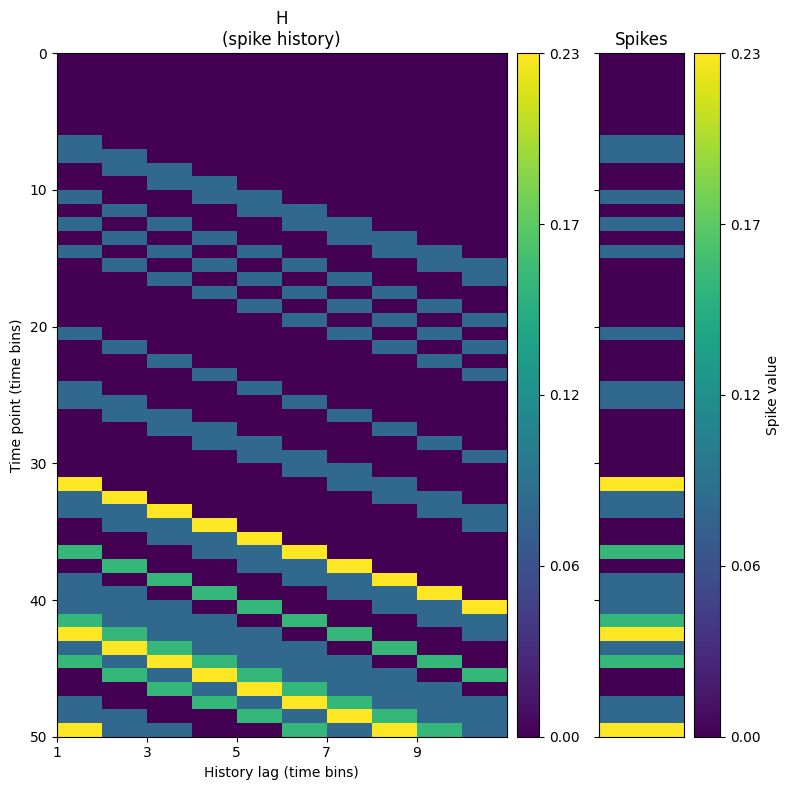

In [19]:
def make_post_spike_matrix(spikes, n_history_bins):
    '''
    Construct a matrix of post-spike history terms.
    spikes: (T,) array of spike counts (0 or 1 for simplicity)
    n_history_bins: number of bins for spike history
    Returns:
        H: (T, n_history_bins) matrix, each column is spike count at lag k
    '''
    T = len(spikes)
    H = np.zeros((T, n_history_bins))
    for t in range(T):
        for k in range(n_history_bins):
            if t - k >= 0:
                H[t, k] = spikes[t - k]
    return H

H = make_post_spike_matrix(spike_data, n_history_bins=10)
print(H.sum())
plot_history_matrices(H, spike_data, nt=50, t0=100)

### (3) Develop Poisson GLM with post spike filter

**Discrete-time Bernoulli-GLM (logistic nonlinearity)**
- Nonlinearity: $p_t = \sigma(\eta_t) = \frac{1}{1 + e^{-\eta_t}}$
- Log-likelihood: $\displaystyle \log \mathcal{L} = \sum_t \big[ y_t\,\log p_t + (1-y_t)\,\log(1-p_t) \big]$
- Output: binary spike indicator per bin ($y_t \in \{0,1\}$)

**Point-process / Poisson-GLM (exp nonlinearity)**
- Nonlinearity: $\exp(\eta_t)$
- Log-likelihood: $\displaystyle \log \mathcal{L} = \sum_t \big[ y_t \log \lambda_t - \lambda_t\,\Delta - \log(y_t!) \big]$
- Output: spike counts per bin ($y_t \sim \mathrm{Poisson}(\lambda_t\,\Delta)$)

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 4.2:</b>

Try implimenting Poisson GLM with post spike filter.
</div>

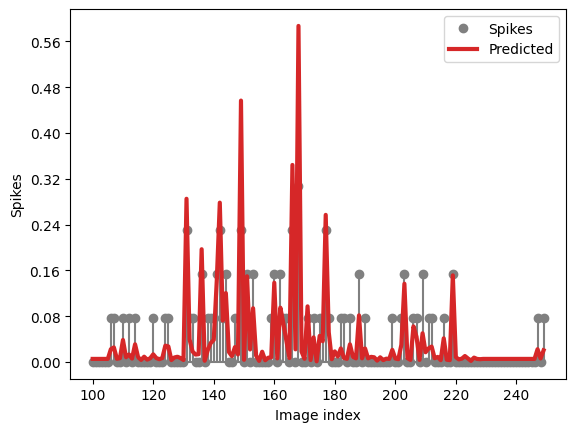

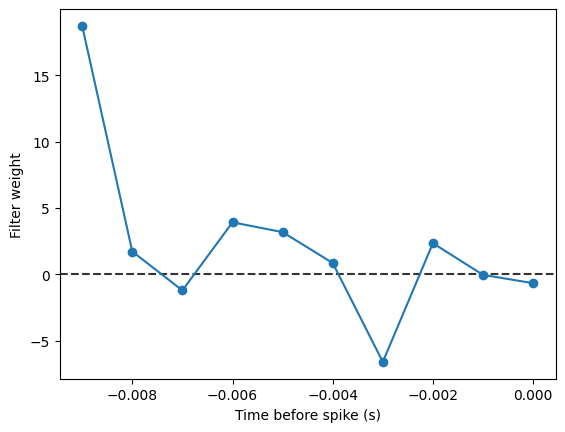

In [20]:
def neg_log_lik_poisson_with_history(theta, X, y):
    neg_log_lik = neg_log_lik_lnp(theta, X, y)
    return neg_log_lik

def fit_glm_with_post_spike_filter(stim_data, spike_data, n_history_bins=10):
    '''
    Fit a Poisson GLM with post-spike filter.
    Returns: predicted firing rate, fitted parameters, and post-spike filter matrix.
    '''
    y = spike_data

    # Construct post-spike history matrix
    H = make_post_spike_matrix(spike_data, n_history_bins)
    # Construct X: bias + make_design_matrix(stim_data) + post-spike history
    X = np.hstack((
        np.ones((len(y), 1)),
        make_design_matrix(stim_data),
        H
    ))

    np.random.seed(0)
    x0 = np.random.normal(0, 0.2, X.shape[1])
    theta = minimize(neg_log_lik_poisson_with_history, x0, args=(X, y), method='BFGS').x
    yhat = np.exp(X @ theta)
    return yhat, theta


n_history_bins = 10
yhat, theta = fit_glm_with_post_spike_filter(stim_data, spike_data, n_history_bins)
# Visualize
plot_spikes_with_prediction(spike_data, yhat, nt=150, t0=100, color="C3")
plot_spike_filter(theta[-n_history_bins:], dt=rgc_data['resolution'])

## 5. MLP with Poisson observation model

In a standard Poisson GLM, the firing rate is a linear function of the inputs followed by an exponential nonlinearity. A Multi-Layer Perceptron (MLP) with a Poisson observation model generalizes this by replacing the linear mapping with a small neural network while keeping the same log-link: the network outputs the log-rate, and an exponential maps it to a nonnegative firing rate.

The MLP:
- Captures nonlinear interactions between stimulus features and spike history that a GLM might miss.
- Still trained by minimizing the Poisson negative log-likelihood (NLL).

Model (one hidden layer):
- Inputs: stimulus design matrix (and optionally post-spike history).
- Hidden: $h = {\rm ReLU}(XW_1 + b_1)$
- Log-rate: $z = h\cdot W_2 + b_2$
- Rate: $\lambda = \exp{z}$
- Loss (Poisson NLL): $\mathcal{L}(\theta) = \sum\limits_t [\lambda_t − y_t \log \lambda_t] + {\rm L2\ regularization}$

Below, we implement a lightweight NumPy MLP trained with full-batch gradient descent on the Poisson NLL using the same `rgc_data` as in the GLM section. We use the design matrix plus a short post-spike history as inputs, then visualize predicted vs. observed spikes.


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 5.1:</b>

Buiding history heatures $H$ and stimulus features $X$ for MLP training.

</div>

In [21]:
# MLP with Poisson observation model (concise, commented)

# Expect previous cells to define: rgc_data, stim_data, spike_data, and helpers
assert 'stim_data' in globals() and 'spike_data' in globals(), "Please run earlier GLM cells first."

# 1) Build inputs: bias + stimulus features + short post-spike history
history_bins = 10
history_features = make_post_spike_matrix(spike_data, history_bins)  # shape: [T, H]
stimulus_features = make_design_matrix(stim_data)             
inputs = np.column_stack([np.ones_like(spike_data),                     # bias
                          stimulus_features, history_features])         # shape: [T, D]
spikes = spike_data.astype(float).reshape(-1, 1)                        # shape: [T, 1]

print(f"inputs.sum: {inputs.sum()}")

inputs.sum: -1028.872539813702


Then we conduct MLP training.

Epoch 500 | train NLL/bin: 0.0832 | val NLL/bin: 0.0362
Epoch 1000 | train NLL/bin: 0.0783 | val NLL/bin: 0.0314
Epoch 1500 | train NLL/bin: 0.0765 | val NLL/bin: 0.0293
Epoch 2000 | train NLL/bin: 0.0758 | val NLL/bin: 0.0285
Epoch 2500 | train NLL/bin: 0.0755 | val NLL/bin: 0.0281
Epoch 3000 | train NLL/bin: 0.0754 | val NLL/bin: 0.0279
Epoch 3500 | train NLL/bin: 0.0753 | val NLL/bin: 0.0278
Epoch 4000 | train NLL/bin: 0.0752 | val NLL/bin: 0.0277


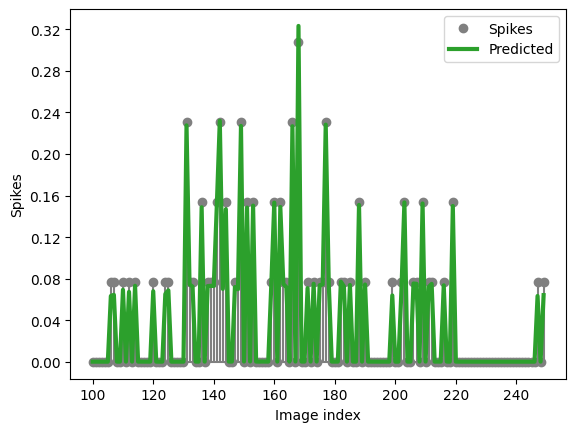

MLP training complete; generated yhat_mlp.


In [22]:
# MLP with Poisson observation model (concise, commented)

# 2) Train/validation split (contiguous to respect temporal structure)
T = len(spikes)
split_idx = int(0.8 * T)
X_train, y_train = inputs[:split_idx], spikes[:split_idx]
X_val, y_val = inputs[split_idx:],  spikes[split_idx:]

# 3) Model: one hidden layer -> log-rate -> exp() rate
rng = np.random.default_rng(0)
input_dim = inputs.shape[1]
hidden_units = 32
W1 = rng.normal(0, 0.1, (input_dim, hidden_units)); b1 = np.zeros((1, hidden_units))
W2 = rng.normal(0, 0.1, (hidden_units, 1));       b2 = np.zeros((1, 1))

def relu(z):
    return np.maximum(0.0, z)

def forward(X):
    h = relu(X @ W1 + b1)          # hidden representation [N, H]
    log_rate = h @ W2 + b2         # log firing rate       [N, 1]
    rate = np.exp(log_rate)        # Poisson mean          [N, 1]
    return h, log_rate, rate

# 4) Poisson NLL with L2 regularization and its gradients
l2 = 1e-4
_eps = 1e-12

def loss_and_grads(X, y):
    h, log_rate, rate = forward(X)
    nll = np.sum(rate - y * log_rate)                     # Σ(λ − y·logλ)
    reg = l2 * (np.sum(W1**2) + np.sum(W2**2))
    loss = nll + reg
    # dL/d(log_rate) = rate − y
    dlog = rate - y                                       # [N, 1]
    dW2 = h.T @ dlog + 2 * l2 * W2
    db2 = dlog.sum(axis=0, keepdims=True)
    dh = dlog @ W2.T
    dh[h <= 0] = 0.0                                      # ReLU backprop
    dW1 = X.T @ dh + 2 * l2 * W1
    db1 = dh.sum(axis=0, keepdims=True)
    return loss, (dW1, db1, dW2, db2)

# 5) Optimize with full-batch gradient descent
lr = 1e-2
epochs = 4000
for epoch in range(1, epochs + 1):
    loss, (gW1, gb1, gW2, gb2) = loss_and_grads(X_train, y_train)
    W1 -= lr * gW1; b1 -= lr * gb1
    W2 -= lr * gW2; b2 -= lr * gb2
    if epoch % 500 == 0:
        _, _, rate_val = forward(X_val)
        val_nll_per_bin = np.mean(rate_val - y_val * np.log(rate_val + _eps))
        print(f"Epoch {epoch:3d} | train NLL/bin: {loss/len(y_train):.4f} | val NLL/bin: {val_nll_per_bin:.4f}")

# 6) Predict over full sequence and visualize
_, _, rate_full = forward(inputs)
yhat_mlp = rate_full.ravel()    # used later by the metrics cell
plot_spikes_with_prediction(spike_data, yhat_mlp, nt=150, t0=100, color="C2")
print("MLP training complete; generated yhat_mlp.")

## 6. Poisson-related metrics

When modeling spike counts with a Poisson observation model, two commonly used metrics are:

1) Bits-per-spike (BPS)
- Measures the information gain (in bits) of the model relative to a homogeneous Poisson (null) model with rate equal to the mean firing rate.
- Higher is better; 0 means no improvement over the null model.
- Definition (for spikes $y_t$ and model rates $\lambda_t$):
  $$
  {\rm BPS} = \frac{1}{N_{spikes}\ln 2}[L({\rm model}) − L({\rm null})]
  $$
  where $L$ means log likelihood (here $L=\sum\limits_t [y_t \log \lambda_t − \lambda_t]$). $L({\rm model})$ takes $\lambda_{t,{\rm model}}$ as the output of the model, and $L({\rm null})$ takes $\lambda_{t,{\rm null}} = {\rm mean}(y)$. $N_{\rm spikes}$ is the total number of spikes.
  - Note that, here $y$ is of shape (300,) and is the neural activity of one neuron in 300ms, averaged over 13 trials. If the data contains spike activity of multiple neurons, the null model should be the mean firing rate of each neuron seperately, rather than the mean firing rate of all neurons.

2) Poisson deviance
- A likelihood-based discrepancy analogous to 2×(NLL difference) between the model and a saturated model that perfectly fits the data.
- Lower is better; 0 indicates a perfect fit (on the training data).
- For observed $y_{n,t}$ and predictions $\hat{\lambda}_{n,t}$ of neuron $n$ and time $t$:
  $$
  D_{\mathrm{Poisson}}=2\sum_{n,t}\left[y_{n,t}\log\frac{y_{n,t}}{\hat{\lambda}_{n,t}}-(y_{n,t}-\hat{\lambda}_{n,t})\right]=2[\log L({\rm perfect})-\log L({\rm model})]
  $$

Below we compute BPS and Poisson deviance for the GLM-with-history (from section 4) and the MLP (from section 5) on the same data using `rgc_data`. We also report per-bin negative log-likelihood for reference.

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 6.1:</b>

Implementing Poisson deviance calculation.

</div>

In [23]:
def poisson_deviance(y, lam, eps=1e-12):
    # Caution: handle y=0 terms by defining 0*log(0/lam)=0
    y = np.asarray(y).ravel()
    lam = np.asarray(lam).ravel()
    mask = y > 0
    term = np.zeros_like(y, dtype=float)
    # Hint: Add eps to both the numerator and denominator in the log, to avoid log(0).
    term[mask] = y[mask] * np.log((y[mask] + eps) / (lam[mask] + eps))
    return 2.0 * np.sum(term - (y - lam))

tmp_y = np.array([0, 1, 2, 0, 1, 2])
tmp_lam = np.array([0.1, 0.9, 2.1, 0.2, 1.2, 1.8])
print(f"Poisson deviance of example:  {poisson_deviance(tmp_y, tmp_lam):.4f}")

Poisson deviance of example:  0.6724


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">
<b>Exercise 6.2:</b>

Implementing BPS calculation.

</div>

In [24]:
def log_likelihood_poisson(y, lam, eps=1e-12):
    y = np.asarray(y).ravel()
    lam = np.asarray(lam).ravel()
    return np.sum(y * np.log(lam + eps) - lam)

def bits_per_spike(y, lam, eps=1e-12):
    y = np.asarray(y).ravel()
    lam = np.asarray(lam).ravel()
    lam_null = np.full_like(y, fill_value=np.mean(y))
    ll_model = log_likelihood_poisson(y, lam, eps)
    ll_null = log_likelihood_poisson(y, lam_null, eps)
    total_spikes = y.sum() + eps
    return (ll_model - ll_null) / (total_spikes * np.log(2))

tmp_y = np.array([0, 1, 2, 0, 1, 2])
tmp_lam = np.array([0.1, 0.9, 2.1, 0.2, 1.2, 1.8])
print(f"BPS of example:  {bits_per_spike(tmp_y, tmp_lam):.4f}")

BPS of example:  0.5858


We check BPS and Poisson deviance of the Poisson GLM and the MLP with Poisson observation model.

In [25]:
# Collect predictions from previous sections
assert 'yhat' in globals() or 'yhat_lnp' in globals(), "Run the GLM-with-history cell above to get yhat."
assert 'yhat_mlp' in globals(), "Run the MLP cell above to get yhat_mlp."

y_true = spike_data
# GLM with history used in section 4 stored predictions in yhat (or yhat_lnp)
yhat_glm = yhat if 'yhat' in globals() else yhat_lnp

# Compute metrics
bps_glm = bits_per_spike(y_true, yhat_glm)
bps_mlp = bits_per_spike(y_true, yhat_mlp)

nll_glm = np.mean(yhat_glm - y_true * np.log(yhat_glm + 1e-12))
nll_mlp = np.mean(yhat_mlp - y_true * np.log(yhat_mlp + 1e-12))

dev_glm = poisson_deviance(y_true, yhat_glm)
dev_mlp = poisson_deviance(y_true, yhat_mlp)

print("Poisson metrics on RGC data (full series):")
print(f"  GLM  | BPS: {bps_glm:.4f} | NLL/bin: {nll_glm:.4f} | Deviance: {dev_glm:.2f}")
print(f"  MLP  | BPS: {bps_mlp:.4f} | NLL/bin: {nll_mlp:.4f} | Deviance: {dev_mlp:.2f}")

Poisson metrics on RGC data (full series):
  GLM  | BPS: 1.8107 | NLL/bin: 0.0758 | Deviance: 6.26
  MLP  | BPS: 2.5085 | NLL/bin: 0.0657 | Deviance: 0.16
